In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

sns.set_style("whitegrid")

***LOAD DATASET***

In [131]:
df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


***DATA PROCESSING***

In [132]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


***NO.OF RESUMES***

In [133]:
print("Total Number of Resumes:")
print(len(df))

Total Number of Resumes:
2484


***CATEGORIES***

In [134]:
print("Unique Categories:")
print(df["Category"].unique())

print("\nNumber of Categories:")
print(df["Category"].nunique())

Unique Categories:
['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']

Number of Categories:
24


***CATEGORY DISTRIBUTION***

In [135]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


***RESUME LENGTH ANALYSIS***

In [136]:
df["Resume_Length"] = df["Resume_str"].apply(
    lambda x: len(str(x).split())
)

df["Resume_Length"].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: Resume_Length, dtype: float64

***AVERAGE RESUME LENGTH***

In [137]:
avg_length = df["Resume_Length"].mean()

print("Average Resume Length:", round(avg_length, 2), "words")

Average Resume Length: 811.33 words


***RESUME LENGTH DISTRIBUTION***

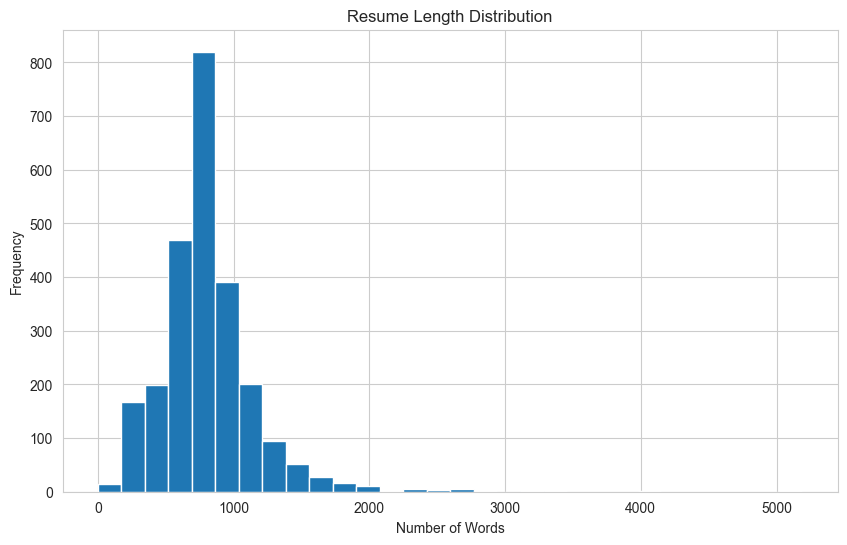

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df["Resume_Length"], bins=30)

plt.title("Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

***SKILL EXTRACTION***

In [139]:
from collections import Counter

skills_list = [
    "python","java","c","c++","sql",
    "html","css","javascript",
    "tensorflow","keras",
    "machine learning","deep learning",
    "nlp","pandas","numpy",
    "power bi","tableau",
    "aws","docker","git","linux"
]

all_skills = []

for resume in df["Resume_str"]:

    resume = str(resume).lower()

    for skill in skills_list:
        if skill in resume:
            all_skills.append(skill)

print("Total Skills Found:", len(all_skills))

Total Skills Found: 3950


***MOST COMMON SKILLS***

In [140]:
skill_counter = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counter.items(),
    columns=["Skill","Frequency"]
)

top_skills = top_skills.sort_values(
    by="Frequency",
    ascending=False
)

top_skills.head(20)

,Skill,Frequency
0,c,2483
2,git,330
1,aws,302
5,sql,191
7,html,158
3,java,98
10,linux,87
8,css,86
4,c++,65
9,javascript,56


***SKILL FREQUENCY CHART***

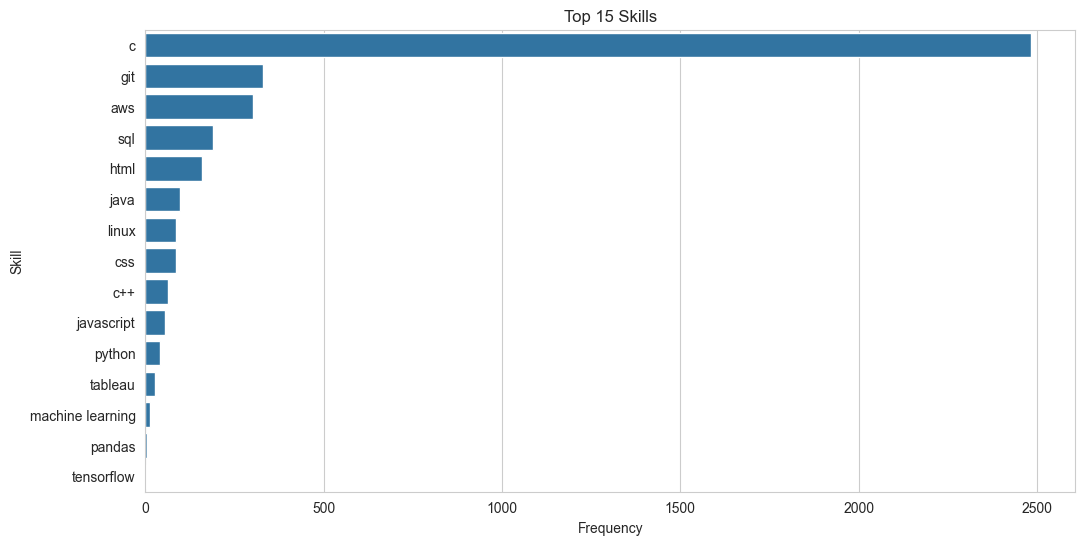

In [141]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_skills.head(15),
    x="Frequency",
    y="Skill"
)

plt.title("Top 15 Skills")
plt.show()

***CATEGORY DISTRIBUTION***

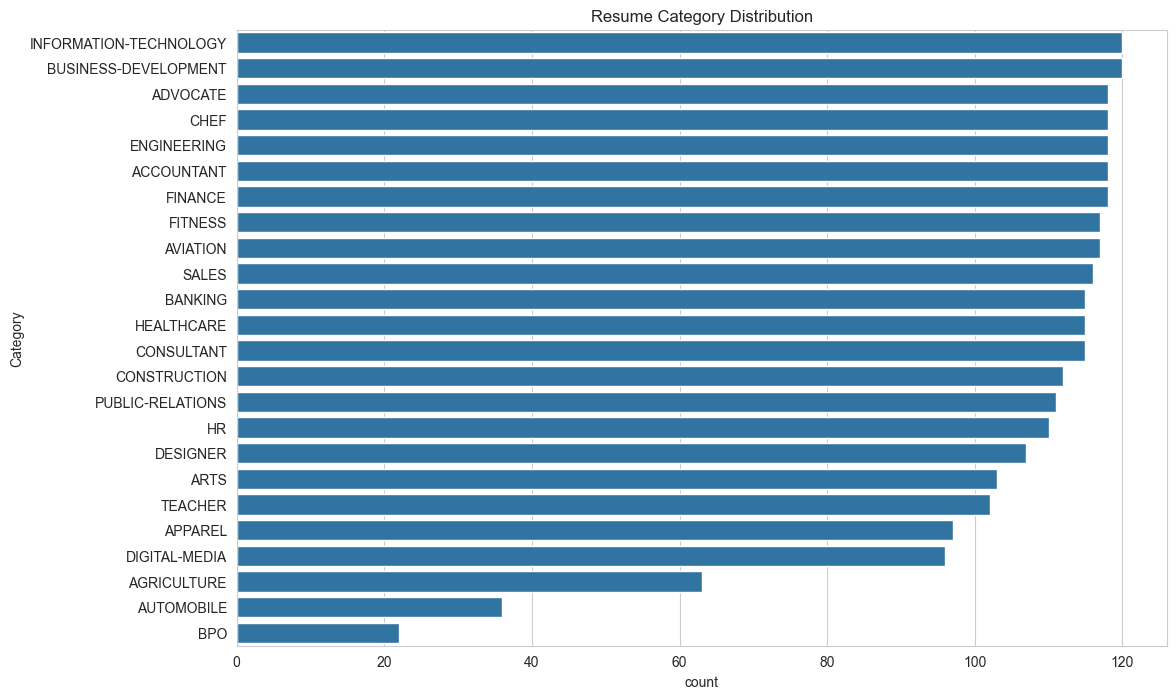

In [142]:
plt.figure(figsize=(12,8))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index
)

plt.title("Resume Category Distribution")
plt.show()

In [143]:
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import TextVectorization

***TEXT SELECTION***

In [144]:
resume_texts = df["Resume_str"].astype(str)
print("Total Resumes:", len(resume_texts))
print("\nSample Resume:\n")
print(resume_texts.iloc[0][:500])

Total Resumes: 2484

Sample Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


***LOWERCASE CONVERSION***

In [145]:
resume_texts = resume_texts.str.lower()
print(resume_texts.iloc[0][:500])

         hr administrator/marketing associate

hr administrator       summary     dedicated customer service manager with 15+ years of experience in hospitality and customer service management.   respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         highlights         focused on customer satisfaction  team management  marketing savvy  conflict resolution techniques     training and development  skilled multi-task


***REMOVAL OF SPECIAL CHARACTERS***

In [146]:
def clean_text(text):
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

***CLEANING***

In [147]:
cleaned_resumes = resume_texts.apply(clean_text)
print(cleaned_resumes.iloc[0][:500])

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missour


***TOKENIZATION & VOCABULARY CREATION***

In [148]:
MAX_TOKENS = 10000
MAX_LENGTH = 200

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

vectorizer.adapt(cleaned_resumes)

***VOCABULARY VIEW***

In [149]:
vocab = vectorizer.get_vocabulary()
print("Vocabulary Size:", len(vocab))
print("\nFirst 50 Vocabulary Words:")
print(vocab[:50])

Vocabulary Size: 10000

First 50 Vocabulary Words:
['', '[UNK]', np.str_('and'), np.str_('to'), np.str_('of'), np.str_('the'), np.str_('in'), np.str_('for'), np.str_('with'), np.str_('a'), np.str_('state'), np.str_('company'), np.str_('city'), np.str_('management'), np.str_('name'), np.str_('on'), np.str_('as'), np.str_('all'), np.str_('sales'), np.str_('customer'), np.str_('business'), np.str_('skills'), np.str_('by'), np.str_('new'), np.str_('s'), np.str_('service'), np.str_('team'), np.str_('development'), np.str_('training'), np.str_('experience'), np.str_('project'), np.str_('i'), np.str_('work'), np.str_('manager'), np.str_('information'), np.str_('marketing'), np.str_('or'), np.str_('that'), np.str_('financial'), np.str_('office'), np.str_('support'), np.str_('education'), np.str_('including'), np.str_('from'), np.str_('staff'), np.str_('at'), np.str_('professional'), np.str_('data'), np.str_('system'), np.str_('systems')]


***TEXT TO TOKENS***

In [150]:
tokenized_resumes = vectorizer(cleaned_resumes)
print("Tokenized Shape:")
print(tokenized_resumes.shape)

Tokenized Shape:
(2484, 200)


***SAMPLE TOKENS***

In [151]:
print(tokenized_resumes[0].numpy())

[ 187  754   35  212  187  754  114  856   19   25   33    8  106    4
   29    6 1663    2   19   25   13 4466 2752    2  397    4   19  552
  282 8603    3    1    9 1849 1533 2054    3   19   25  262  552   15
   19  314   26   13   35 2176  993  456  404   28    2   27  624  321
 2202   56  118  227  246 3562 3898  334   28  487  233   22    1    6
   19 1816    2   35   22 3639 6036 2630  133   33   28  487 1447  915
    7  464  292 1663   49  128   16 6036    1    1 8732 6295    1 8732
 4755   48    1    1  276  851    2 1316    6   19   25   18  207   91
  115  943 1389  113   77   13   86    2   82  734   29  187  754   35
  212  187  754 1324    3   70   11   14   12   10 4640    3  157  122
 4652    2 2509  104  128   16  716  808  762  118  326   28    2  103
   66 1914  103 5208 3206    2  219  193 5604  188    4  326  131 1641
  128   16  273    2 4765  176  165  443  128   16 1207  742 1839   82
  606    2 2514    2  103 1355    7  453  129 8528   13    6  240  456
    4 

***REVERSE MAPPING***

In [152]:
index_to_word = dict(enumerate(vocab))
sample_tokens = tokenized_resumes[0].numpy()[:30]
decoded_words = [
    index_to_word.get(token, "")
    for token in sample_tokens
]
print(decoded_words)

[np.str_('hr'), np.str_('administrator'), np.str_('marketing'), np.str_('associate'), np.str_('hr'), np.str_('administrator'), np.str_('summary'), np.str_('dedicated'), np.str_('customer'), np.str_('service'), np.str_('manager'), np.str_('with'), np.str_('years'), np.str_('of'), np.str_('experience'), np.str_('in'), np.str_('hospitality'), np.str_('and'), np.str_('customer'), np.str_('service'), np.str_('management'), np.str_('respected'), np.str_('builder'), np.str_('and'), np.str_('leader'), np.str_('of'), np.str_('customer'), np.str_('focused'), np.str_('teams'), np.str_('strives')]


***PADDING VERIFICATION***

In [153]:
print("Length of Resume 1:")
print(len(tokenized_resumes[0]))
print("Length of Resume 2:")
print(len(tokenized_resumes[1]))

Length of Resume 1:
200
Length of Resume 2:
200


***ENCODE CATEGORIES***

In [154]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Category"])
num_classes = len(label_encoder.classes_)
print("Number of Categories:", num_classes)

Number of Categories: 24


***TRAIN TEST SPLIT***

In [155]:
from sklearn.model_selection import train_test_split
X = tokenized_resumes.numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(1987, 200)
(497, 200)


***MODEL COMPONENTS***

In [156]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    Dense,
    GlobalAveragePooling1D,
    LayerNormalization
)
from tensorflow.keras.models import Model

***BUILD BASELINE MODEL***

In [157]:
vocab_size = len(vectorizer.get_vocabulary())
embedding_dim = 128
inputs = Input(shape=(200,))
# Embedding
x = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(inputs)

# Self Attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(
    query=x,
    value=x,
    key=x
)

# Residual Connection
x = x + attention_output
# Normalize
x = LayerNormalization()(x)
# Pool
x = GlobalAveragePooling1D()(x)
# Dense
x = Dense(
    128,
    activation="relu"
)(x)
outputs = Dense(
    num_classes,
    activation="softmax"
)(x)
baseline_model = Model(inputs, outputs)
baseline_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 200, 128)  │  1,280,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 128)  │     66,048 │ embedding_8[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_8[0][0… │
│                     │                   │            │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 128)  │          0 │ embedding_8[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24)        │      3,096 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,365,912 (5.21 MB)

 Trainable params: 1,365,912 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

***COMPILE MODEL***

In [158]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

***TRAIN START TIME***

In [159]:
import time
start_time = time.time()

***TRAIN MODEL***

In [160]:
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.2796 - loss: 2.7909 - val_accuracy: 0.4171 - val_loss: 2.3281
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.6258 - loss: 1.4659 - val_accuracy: 0.5628 - val_loss: 1.6741
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8557 - loss: 0.5881 - val_accuracy: 0.5678 - val_loss: 1.6933
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9726 - loss: 0.1501 - val_accuracy: 0.5829 - val_loss: 1.7447
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9966 - loss: 0.0382 - val_accuracy: 0.6131 - val_loss: 1.8181
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 0.6181 - val_loss: 1.8510
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.6231 - val_loss: 1.8886
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.6231 - v

***RECORD TRAIN TIME***

In [161]:
end_time = time.time()
training_time = end_time - start_time
print("Training Time:", round(training_time,2), "seconds")

Training Time: 36.61 seconds


***EVALUATE MODEL***

In [162]:
loss, accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Test Loss:", round(loss,4))
print("Test Accuracy:", round(accuracy*100,2), "%")

Test Loss: 1.9559
Test Accuracy: 63.38 %


***ACCURACY GRAPH***

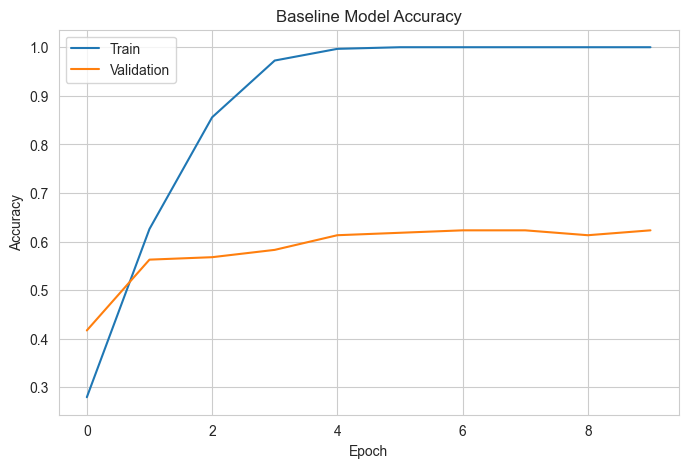

In [163]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend([
    "Train",
    "Validation"
])
plt.show()

***LOSS GRAPH***

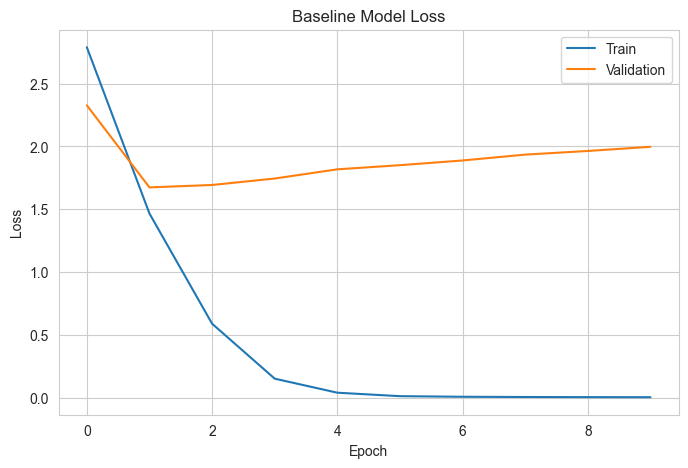

In [164]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend([
    "Train",
    "Validation"
])
plt.show()

***ACCURACY VS LOSS**

In [165]:
baseline_accuracy = accuracy
baseline_loss = loss
baseline_training_time = training_time
print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Loss:", baseline_loss)
print("Baseline Time:", baseline_training_time)

Baseline Accuracy: 0.6338028311729431
Baseline Loss: 1.9559179544448853
Baseline Time: 36.606539249420166


***POSITIONAL ENCODING FUNCTION***

In [166]:
import numpy as np
import tensorflow as tf
def positional_encoding(position, d_model):
    positions = np.arange(position)[:, np.newaxis]
    dimensions = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(
        10000,
        (2 * (dimensions // 2)) / np.float32(d_model)
    )
    angle_rads = positions * angle_rates
    pos_encoding = np.zeros((position, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding, dtype=tf.float32)

***GENERATE POSITIONAL ENCODING***

In [167]:
d_model = 128
max_position = 200
PE = positional_encoding(
    position=max_position,
    d_model=d_model
)
print("Shape:", PE.shape)

Shape: (200, 128)


In [168]:
seq_len = embedded.shape[0]
PE = positional_encoding(
    position=seq_len,
    d_model=128
)

position_aware_embeddings = embedded + PE

print(position_aware_embeddings.shape)

(30, 128)


In [169]:
print(PE[:5, :10].numpy())

[[ 0.          1.          0.          1.          0.          1.
   0.          1.          0.          1.        ]
 [ 0.84147096  0.5403023   0.7617204   0.6479059   0.68156135  0.731761
   0.604694    0.7964579   0.53316844  0.84600914]
 [ 0.9092974  -0.41614684  0.98704624 -0.16043596  0.99748     0.07094825
   0.9632266   0.2686903   0.9021307   0.43146282]
 [ 0.14112    -0.9899925   0.51730573 -0.8558007   0.7782725  -0.62792665
   0.9296448  -0.36845687  0.9932532  -0.11596614]
 [-0.7568025  -0.6536436  -0.31671542 -0.9485206   0.14153892 -0.9899327
   0.5176193  -0.855611    0.77847177 -0.62767965]]


***EMBEDDING LAYER***

In [170]:
embedding_dim = 128
embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(vectorizer.get_vocabulary()),
    output_dim=embedding_dim
)

In [171]:
embedded = embedding_layer(sample_tokens)   # (30,128)
position_aware_embeddings = embedded + PE[:30, :]

***ADD PE TO EMBEDDINGS***

In [172]:
embedded = embedding_layer(sample_tokens)
position_aware_embeddings = embedded + PE[tf.newaxis, :, :]

In [173]:
sample_text = ["python machine learning engineer"]

sample_tokens = vectorizer(sample_text)

embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(vectorizer.get_vocabulary()),
    output_dim=128
)

word_embeddings = embedding_layer(sample_tokens)

print("Embedding Shape:")
print(word_embeddings.shape)

# Get sequence length
seq_len = word_embeddings.shape[1]

# Create matching positional encoding
PE = positional_encoding(
    position=seq_len,
    d_model=128
)

position_aware_embeddings = (
    word_embeddings +
    PE[tf.newaxis, :, :]
)

print("PE Shape:")
print(PE.shape)

print("Position Aware Shape:")
print(position_aware_embeddings.shape)

Embedding Shape:
(1, 200, 128)
PE Shape:
(200, 128)
Position Aware Shape:
(1, 200, 128)


***POSITIONAL ENCODING LAYER***

In [174]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        positions = np.arange(max_len)[:, np.newaxis]
        dimensions = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(
            10000,
            (2 * (dimensions // 2)) / np.float32(d_model)
        )
        angle_rads = positions * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pe = tf.constant(pe, dtype=tf.float32)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:seq_len, :]

***PARAMETERS***

In [175]:
MAX_LENGTH = 200
VOCAB_SIZE = len(vectorizer.get_vocabulary())
EMBEDDING_DIM = 128
NUM_CLASSES = len(label_encoder.classes_)

***BUILD MODEL***

In [176]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    Dense,
    GlobalAveragePooling1D,
    LayerNormalization,
    Dropout
)
from tensorflow.keras.models import Model

In [177]:
inputs = Input(shape=(MAX_LENGTH,))
# Embedding
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(inputs)

# Positional Encoding
x = PositionalEncoding(
    max_len=MAX_LENGTH,
    d_model=EMBEDDING_DIM
)(x)

# Multi-Head Self Attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(
    query=x,
    value=x,
    key=x
)

# Residual Connection
x = x + attention_output

# Normalization
x = LayerNormalization()(x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Dense Layer
x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

improved_model = Model(inputs, outputs)

improved_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 200, 128)  │  1,280,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 200, 128)  │          0 │ embedding_11[0][… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 128)  │     66,048 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 200, 128)  │          0 │ positional_encod… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 24)        │      3,096 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,365,912 (5.21 MB)

 Trainable params: 1,365,912 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

***COMPILE MODEL***

In [178]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

***RECORD TRAINING TIME***

In [179]:
import time

start_time = time.time()


***TRAIN THE MODEL***

In [180]:
history_pe = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.0408 - loss: 3.1857 - val_accuracy: 0.0503 - val_loss: 3.1714
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.0632 - loss: 3.1415 - val_accuracy: 0.0503 - val_loss: 3.1610
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.0777 - loss: 3.1006 - val_accuracy: 0.1357 - val_loss: 3.0446
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.4038 - loss: 2.1647 - val_accuracy: 0.5528 - val_loss: 1.5263
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6672 - loss: 1.2496 - val_accuracy: 0.6332 - val_loss: 1.3806
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7422 - loss: 0.9944 - val_accuracy: 0.6784 - val_loss: 1.2716
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.7802 - loss: 0.8424 - val_accuracy: 0.6683 - val_loss: 1.4242
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8037 - loss: 0.7552 - val_accuracy: 0.6533 - v

***CALCULATE TRAINING TIME***

In [181]:
end_time = time.time()

pe_training_time = end_time - start_time

print("Training Time:", round(pe_training_time,2), "seconds")

Training Time: 202.13 seconds


***EVALUATE THE MODEL***

In [182]:
pe_loss, pe_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(pe_accuracy*100,2), "%")
print("Test Loss:", round(pe_loss,4))

Test Accuracy: 71.23 %
Test Loss: 1.1715


***ACCURACY GRAPH***

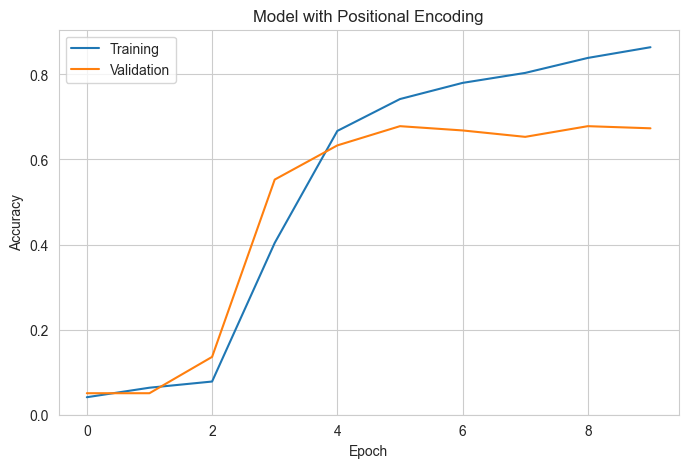

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_pe.history["accuracy"])
plt.plot(history_pe.history["val_accuracy"])

plt.title("Model with Positional Encoding")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

***LOSS GRAPH***

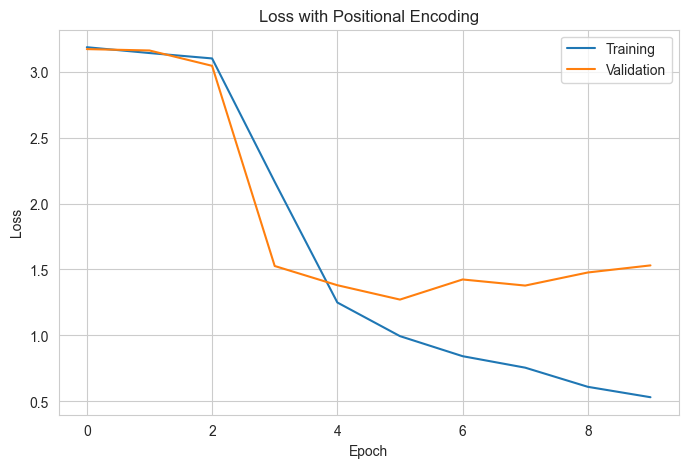

In [184]:
plt.figure(figsize=(8,5))

plt.plot(history_pe.history["loss"])
plt.plot(history_pe.history["val_loss"])

plt.title("Loss with Positional Encoding")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

***COMPARISION GRAPH***

In [185]:
comparison = {
    "Metric": ["Accuracy", "Loss", "Training Time"],
    "Baseline": [
        baseline_accuracy,
        baseline_loss,
        baseline_training_time
    ],
    "With_Positional_Encoding": [
        pe_accuracy,
        pe_loss,
        pe_training_time
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Metric,Baseline,With_Positional_Encoding
0,Accuracy,0.633803,0.712274
1,Loss,1.955918,1.171505
2,Training Time,36.606539,202.125884


***COMPARISION TABLE***

In [186]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Loss", "Training Time (sec)"],
    "Without PE": [
        round(baseline_accuracy,4),
        round(baseline_loss,4),
        round(baseline_training_time,2)
    ],
    "With PE": [
        round(pe_accuracy,4),
        round(pe_loss,4),
        round(pe_training_time,2)
    ]
})

comparison

,Metric,Without PE,With PE
0,Accuracy,0.6338,0.7123
1,Loss,1.9559,1.1715
2,Training Time (sec),36.6100,202.1300


***ACCURACY COMPARISION CHART***


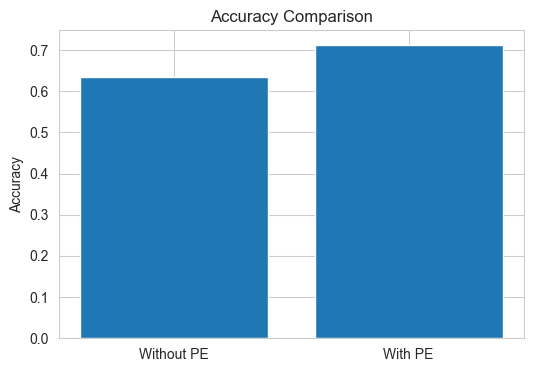

In [187]:
plt.figure(figsize=(6,4))

models = ["Without PE", "With PE"]
accuracies = [baseline_accuracy, pe_accuracy]

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

***LOSS COMPARISION CHART***

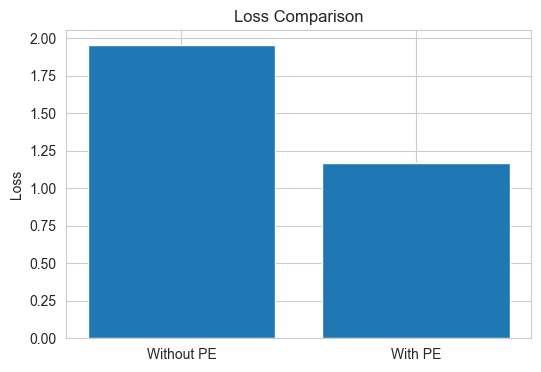

In [188]:
plt.figure(figsize=(6,4))

models = ["Without PE", "With PE"]
losses = [baseline_loss, pe_loss]

plt.bar(models, losses)

plt.title("Loss Comparison")
plt.ylabel("Loss")

plt.show()

***PREPARE SENTENCES***

In [189]:
sentence1 = ["Python developer with 5 years experience in AI"]

sentence2 = ["AI experience with Python developer 5 years"]

***TOKENIZE***

In [190]:
tokens1 = vectorizer(sentence1)

tokens2 = vectorizer(sentence2)

print("Sentence 1 Tokens:")
print(tokens1.numpy()[0][:20])

print("\nSentence 2 Tokens:")
print(tokens2.numpy()[0][:20])

Sentence 1 Tokens:
[2518 1509    8    1  106   29    6 7024    0    0    0    0    0    0
    0    0    0    0    0    0]

Sentence 2 Tokens:
[7024   29    8 2518 1509    1  106    0    0    0    0    0    0    0
    0    0    0    0    0    0]


***GENERATE EMBEDDINGS***

In [191]:
embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(vectorizer.get_vocabulary()),
    output_dim=128
)

emb1 = embedding_layer(tokens1)

emb2 = embedding_layer(tokens2)

print(emb1.shape)
print(emb2.shape)

(1, 200, 128)
(1, 200, 128)


***GENERATE POSITIONAL ENCODING***

In [193]:
PE = positional_encoding(
    position=tokens1.shape[1],
    d_model=128
)

print(PE.shape)

(200, 128)


***ADD POSITIONAL INFORMATION***

In [194]:
position_aware_1 = emb1 + PE[tf.newaxis,:,:]

position_aware_2 = emb2 + PE[tf.newaxis,:,:]

print(position_aware_1.shape)
print(position_aware_2.shape)

(1, 200, 128)
(1, 200, 128)


***COMPARE FEW POSITIONS***

In [195]:
print("Sentence 1 Position 0:")
print(position_aware_1[0,0,:10].numpy())

print("\nSentence 2 Position 0:")
print(position_aware_2[0,0,:10].numpy())

Sentence 1 Position 0:
[ 0.00720514  0.99369353  0.00444676  1.0423074   0.00746597  0.98531246
  0.01089802  1.0471461  -0.03909373  1.0057944 ]

Sentence 2 Position 0:
[ 1.2960285e-04  9.6409118e-01  3.2458473e-02  1.0108520e+00
  4.0469479e-02  9.9564594e-01  6.9726817e-03  1.0366311e+00
 -4.1355301e-02  1.0315071e+00]


***VISUALIZE POSITIONAL ENCODING***

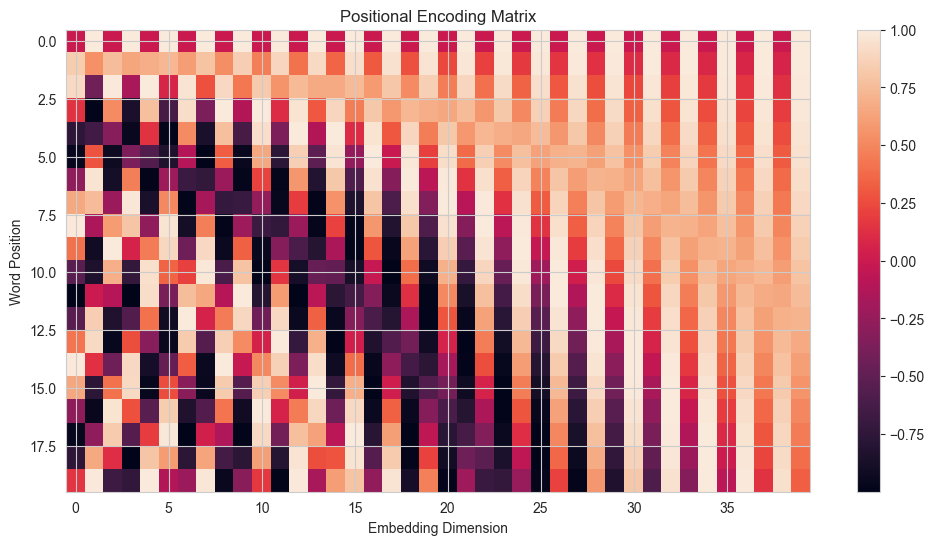

In [196]:
plt.figure(figsize=(12,6))

plt.imshow(
    PE[:20,:40],
    aspect='auto'
)

plt.colorbar()

plt.title("Positional Encoding Matrix")
plt.xlabel("Embedding Dimension")
plt.ylabel("Word Position")

plt.show()

***DEFINE SENTENCES***

In [197]:
sentence1 = ["Python developer with 5 years experience in AI"]

sentence2 = ["AI experience with Python developer 5 years"]

print("Sentence 1:")
print(sentence1[0])

print("\nSentence 2:")
print(sentence2[0])

Sentence 1:
Python developer with 5 years experience in AI

Sentence 2:
AI experience with Python developer 5 years


***TOKENIZE SENTENCES***

In [198]:
tokens1 = vectorizer(sentence1)
tokens2 = vectorizer(sentence2)

print("Sentence 1 Tokens:")
print(tokens1.numpy()[0][:15])

print("\nSentence 2 Tokens:")
print(tokens2.numpy()[0][:15])

Sentence 1 Tokens:
[2518 1509    8    1  106   29    6 7024    0    0    0    0    0    0
    0]

Sentence 2 Tokens:
[7024   29    8 2518 1509    1  106    0    0    0    0    0    0    0
    0]


***CREATE EMBEDDINGS***

In [199]:
embedding_dim = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(vectorizer.get_vocabulary()),
    output_dim=embedding_dim
)

emb1 = embedding_layer(tokens1)
emb2 = embedding_layer(tokens2)

print(emb1.shape)
print(emb2.shape)

(1, 200, 128)
(1, 200, 128)


***GENERATE POSITIONAL ENCODING***

In [200]:
PE = positional_encoding(
    position=tokens1.shape[1],
    d_model=embedding_dim
)

print(PE.shape)

(200, 128)


***ADD POSITIONAL INFORMATION***

In [201]:
pos_emb1 = emb1 + PE[tf.newaxis,:,:]
pos_emb2 = emb2 + PE[tf.newaxis,:,:]

***COMPARE POSITION AWARE EMBEDDINGS***

In [202]:
print("Sentence 1 - First Word Vector")
print(pos_emb1[0,0,:10].numpy())

print("\nSentence 2 - First Word Vector")
print(pos_emb2[0,0,:10].numpy())

Sentence 1 - First Word Vector
[-1.8487535e-02  1.0463992e+00  9.5261559e-03  9.9995661e-01
  1.4466021e-02  9.6534407e-01 -4.8476364e-02  1.0155860e+00
 -7.3102862e-04  1.0358163e+00]

Sentence 2 - First Word Vector
[-0.01200057  1.0008217  -0.01051409  0.95883644  0.04622617  0.9829478
 -0.04783343  0.9686231  -0.00215675  1.0083758 ]


In [203]:
vocab = vectorizer.get_vocabulary()

python_id = vocab.index("python")

print("Python Token ID:", python_id)

Python Token ID: 2518


***POSITIONAL ENCODING MATRIX***

In [204]:
d_model = 128
max_position = 200

PE = positional_encoding(
    position=max_position,
    d_model=d_model
)

***HEATMAP VISUALIZATION***


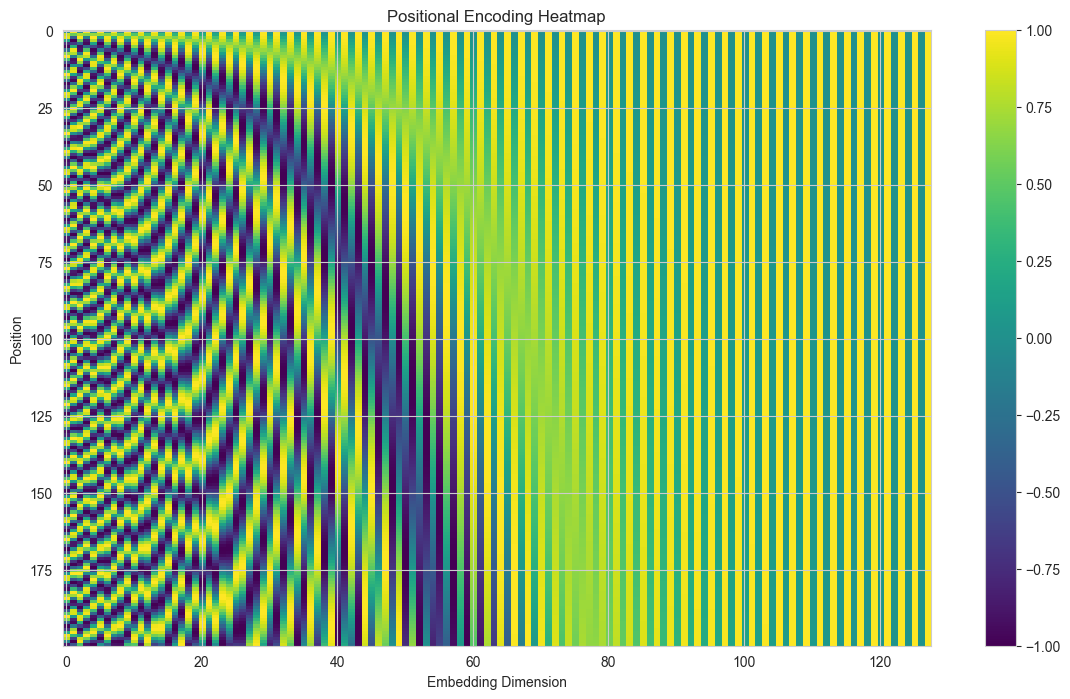

In [205]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.imshow(
    PE.numpy(),
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.title("Positional Encoding Heatmap")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.show()

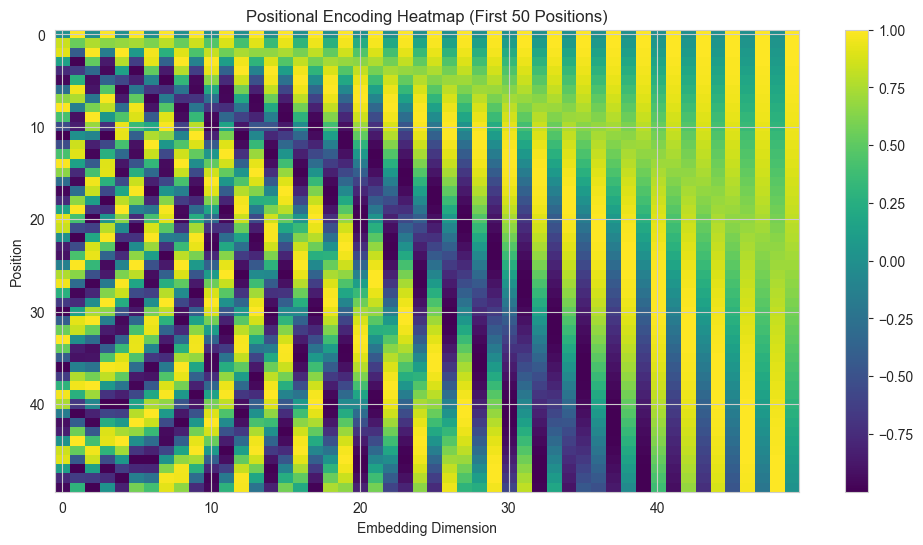

In [206]:
plt.figure(figsize=(12,6))

plt.imshow(
    PE[:50,:50].numpy(),
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.title("Positional Encoding Heatmap (First 50 Positions)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.show()

***SAVE THE MODEL***


In [207]:
improved_model.save("model.keras")

print("Model saved successfully.")

Model saved successfully.


In [208]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Tokenizer saved.")

Tokenizer saved.


In [209]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder saved.")

Label Encoder saved.
